# Higher Stakes, Higher Trust?
**Supplementary material for UMAP 2026 Submission**

Notebook for running statistical analysis on particpant performance metrics.  

Be sure to update path information to location of results files. And you can skip the section "Load and Preprocess Participant Data" since this is already been processed for each participant


In [2]:
import sys
sys.path.append('../')

In [3]:
from pathlib import Path
import numpy as np 
from PIL import Image

import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import utils
import metrics
sns.set(style="whitegrid")

In [4]:
from pymer4.models import glmer, lmer

In [5]:
from pymer4 import test_install
test_install()

All required R libraries found:
('lmerTest', 'emmeans', 'tidyverse', 'broom', 'broom.mixed', 'arrow', 'report')
Installation working successfully!


# Notebook and File Paths Setup

In [6]:
results_basepath = Path('../../output') / 'preprocessed_results'
df_low = pd.read_csv(results_basepath / 'per_sample_results_low.csv')
df_high = pd.read_csv(results_basepath / 'per_sample_results_high.csv')
df_all = pd.concat([df_low, df_high], axis=0).reset_index(drop=True)

df_all["stakes_level"] = pd.Categorical(
    df_all["stakes_level"],
    categories=["low", "high"],  # first = reference
    ordered=True
)
df_all['time_taken_advised'] = df_all['time_taken_advised'] / 1000  # convert ms to s
df_all['z_time_taken_advised'] = (df_all['time_taken_advised'] - df_all['time_taken_advised'].mean()) / df_all['time_taken_advised'].std()
df_all['log_time_taken_advised'] = np.log(df_all['time_taken_advised'].clip(1e-3))  # avoid log(0)
df_all['z_log_time'] = (df_all['log_time_taken_advised'] - df_all['log_time_taken_advised'].mean()) / df_all['log_time_taken_advised'].std()

df_low = df_all[df_all['stakes_level'] == 'low'].copy()
df_high = df_all[df_all['stakes_level'] == 'high'].copy()

In [7]:
display(df_low.head())
display(df_high.head())

,part_id,blocky_id,stakes_level,y_true,y_pred,y_user_base,y_user_advised,time_taken_base,time_taken_advised,z_time_taken_advised,log_time_taken_advised,z_log_time
0,study1-05,0575626d-1155-4f79-a8ed-151c82499cee,low,0,0,1,0,2596.0,3.797,-0.364812,1.334211,-0.460148
1,study1-05,09a4fcaa-a63d-4a51-a177-4b22a8da18bf,low,1,1,0,0,2573.0,3.342,-0.424082,1.206569,-0.659876
2,study1-05,0a43a265-1afa-47a5-807e-402622e5b3c8,low,0,0,1,0,2010.0,4.397,-0.286653,1.480922,-0.230580
3,study1-05,0a6a8b66-04f9-443f-a92f-8da31418674a,low,0,0,0,0,5063.0,3.973,-0.341885,1.379521,-0.389248
4,study1-05,0ec401e3-48a9-44e3-807c-e950d9f84760,low,0,1,0,0,2670.0,4.608,-0.259167,1.527794,-0.157237


,part_id,blocky_id,stakes_level,y_true,y_pred,y_user_base,y_user_advised,time_taken_base,time_taken_advised,z_time_taken_advised,log_time_taken_advised,z_log_time
958,study1-11,0575626d-1155-4f79-a8ed-151c82499cee,high,0,0,1,0,5943.0,7.809,0.157813,2.055277,0.668147
959,study1-11,09a4fcaa-a63d-4a51-a177-4b22a8da18bf,high,1,1,0,0,4897.0,7.158,0.073010,1.968231,0.531941
960,study1-11,0a43a265-1afa-47a5-807e-402622e5b3c8,high,0,0,0,0,6839.0,3.257,-0.435155,1.180807,-0.700189
961,study1-11,0a6a8b66-04f9-443f-a92f-8da31418674a,high,0,0,1,1,5023.0,6.091,-0.065983,1.806812,0.279360
962,study1-11,0ec401e3-48a9-44e3-807c-e950d9f84760,high,0,1,1,1,3774.0,7.697,0.143223,2.040831,0.645542


# Appropiateness of Reliance Analysis

In [8]:
user_AoRs_low = []
user_ids = df_low['part_id'].unique()
for i, uid in enumerate(user_ids):
    df_part = df_low[df_low['part_id'] == uid]
    AoR = metrics.calc_AoR(y_true=df_part['y_true'], 
                           y_model=df_part['y_pred'],
                           y_user_base=df_part['y_user_base'],
                           y_user_advised=df_part['y_user_advised'])
    user_AoRs_low.append(AoR)
user_AoRs_low = np.array(user_AoRs_low)
user_AoRs_low.shape

(24, 2)

In [9]:
user_AoRs_high = []
user_ids = df_high['part_id'].unique()
for i, uid in enumerate(user_ids):
    df_part = df_high[df_high['part_id'] == uid]
    AoR = metrics.calc_AoR(y_true=df_part['y_true'], 
                           y_model=df_part['y_pred'],
                           y_user_base=df_part['y_user_base'],
                           y_user_advised=df_part['y_user_advised'])
    user_AoRs_high.append(AoR)
user_AoRs_high = np.array(user_AoRs_high)
user_AoRs_high.shape

(28, 2)

In [10]:
rair_low = user_AoRs_low[:, 0]
rsr_low = user_AoRs_low[:, 1]

rair_high = user_AoRs_high[:, 0]
rsr_high = user_AoRs_high[:, 1]

In [11]:
rsr_high

array([0.33333333, 0.33333333, 0.33333333, 0.        , 0.25      ,
       0.16666667, 0.        , 0.16666667, 0.16666667, 0.25      ,
       0.33333333, 0.33333333, 0.33333333, 0.41666667, 0.25      ,
       0.08333333, 0.33333333, 0.5       , 0.5       , 0.16666667,
       0.41666667, 0.33333333, 0.25      , 0.5       , 0.75      ,
       0.5       , 0.16666667, 0.25      ])

0.6125 0.4166666666666667 0.6666666666666666 0.3333333333333333
ConfidenceInterval(low=np.float64(0.46153846153846156), high=np.float64(0.75)) ConfidenceInterval(low=np.float64(0.3333333333333333), high=np.float64(0.5833333333333334)) ConfidenceInterval(low=np.float64(0.5419580419580419), high=np.float64(0.7)) ConfidenceInterval(low=np.float64(0.25), high=np.float64(0.3333333333333333))


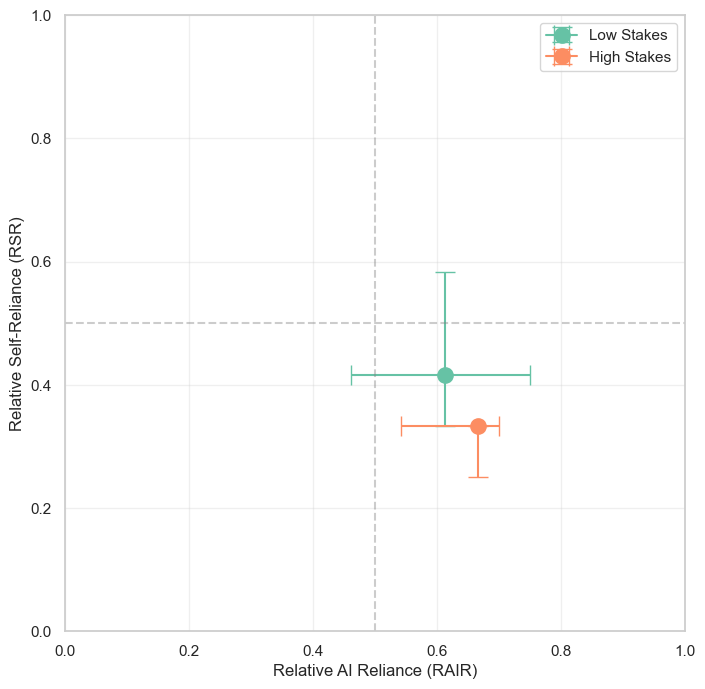

In [12]:
# Calculate means and standard errors for both conditions
mean_low_x = np.mean(rair_low)
mean_low_y = np.mean(rsr_low)
se_low_x = np.std(rair_low) / np.sqrt(len(rair_low))
se_low_y = np.std(rsr_low) / np.sqrt(len(rsr_low))

median_low_x = np.median(rair_low)
median_low_y = np.median(rsr_low)
ci_low_x = stats.bootstrap((rair_low,), np.median, confidence_level=0.95, n_resamples=10000, method='percentile').confidence_interval
ci_low_y = stats.bootstrap((rsr_low,), np.median, confidence_level=0.95, n_resamples=10000, method='percentile').confidence_interval


mean_high_x = np.mean(rair_high)
mean_high_y = np.mean(rsr_high)
se_high_x = np.std(rair_high) / np.sqrt(len(rair_high))
se_high_y = np.std(rsr_high) / np.sqrt(len(rsr_high))

median_high_x = np.median(rair_high)
median_high_y = np.median(rsr_high)
ci_high_x = stats.bootstrap((rair_high,), np.median, confidence_level=0.95, n_resamples=10000, method='percentile').confidence_interval
ci_high_y = stats.bootstrap((rsr_high,), np.median, confidence_level=0.95, n_resamples=10000, method='percentile').confidence_interval

print(median_low_x, median_low_y, median_high_x, median_high_y)
print(ci_low_x, ci_low_y, ci_high_x, ci_high_y)

x_low = median_low_x
x_err_low = np.array([[median_low_x - ci_low_x.low], [ci_low_x.high - median_low_x]])
x_high = median_high_x
x_err_high = np.array([[median_high_x - ci_high_x.low], [ci_high_x.high - median_high_x]])

y_low = median_low_y
y_err_low = np.array([[median_low_y - ci_low_y.low], [ci_low_y.high - median_low_y]])
y_high = median_high_y
y_err_high = np.array([[median_high_y - ci_high_y.low], [ci_high_y.high - median_high_y]])

# Create the plot
colors = sns.color_palette("Set2", 2)
plt.figure(figsize=(8, 8))
plt.errorbar(x_low, y_low, xerr=x_err_low, yerr=y_err_low, 
  marker='o', markersize=11, label='Low Stakes', capsize=7, color=colors[0])
plt.errorbar(x_high, y_high, xerr=x_err_high, yerr=y_err_high, 
       marker='o', markersize=11, label='High Stakes', capsize=7, color=colors[1])

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4)

plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xlabel('Relative AI Reliance (RAIR)')
plt.ylabel('Relative Self-Reliance (RSR)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../output/figures/AoR_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
print(f'RAIR Low Stakes: Median={median_low_x:.3f}, 95% CI=({ci_low_x.low:.3f}, {ci_low_x.high:.3f})')
print(f'RAIR High Stakes: Median={median_high_x:.3f}, 95% CI=({ci_high_x.low:.3f}, {ci_high_x.high:.3f})')
print(f'RSR Low Stakes: Median={median_low_y:.3f}, 95% CI=({ci_low_y.low:.3f}, {ci_low_y.high:.3f})')
print(f'RSR High Stakes: Median={median_high_y:.3f}, 95% CI=({ci_high_y.low:.3f}, {ci_high_y.high:.3f})')

RAIR Low Stakes: Median=0.613, 95% CI=(0.462, 0.750)
RAIR High Stakes: Median=0.667, 95% CI=(0.542, 0.700)
RSR Low Stakes: Median=0.417, 95% CI=(0.333, 0.583)
RSR High Stakes: Median=0.333, 95% CI=(0.250, 0.333)


In [14]:
# print('---')
# print('For Latex Table:')
print(f'RAIR & {median_low_x:.2f} ({ci_low_x.low:.2f}, {ci_low_x.high:.2f}) & {median_high_x:.2f} ({ci_high_x.low:.2f}, {ci_high_x.high:.2f}) & & \\\\')
print(f'RSR & {median_low_y:.2f} ({ci_low_y.low:.2f}, {ci_low_y.high:.2f}) & {median_high_y:.2f} ({ci_high_y.low:.2f}, {ci_high_y.high:.2f}) & & \\\\')

RAIR & 0.61 (0.46, 0.75) & 0.67 (0.54, 0.70) & & \\
RSR & 0.42 (0.33, 0.58) & 0.33 (0.25, 0.33) & & \\


In [15]:
from scipy.stats import mannwhitneyu, wilcoxon, shapiro, ttest_ind, ttest_rel, levene

In [16]:
## Functions for effect size
def cohen_r_mwu(g1, g2, u):
    n1, n2 = len(g1), len(g2)
    mu_u = n1 * n2 / 2
    sigma_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    
    z= (u - mu_u) / sigma_u
    return z / np.sqrt(n1 + n2)

In [17]:
stat, p = shapiro(rair_low)
print(f'Shapiro-Wilk test for RAIR Low Stakes: stat={stat:.4f}, p={p:.4f} - {"Normal" if p < 0.05 else "Not Normal"}')
stat, p = shapiro(rair_high)
print(f'Shapiro-Wilk test for RAIR High Stakes: stat={stat:.4f}, p={p:.4f} - {"Normal" if p < 0.05 else "Not Normal"  }')

Shapiro-Wilk test for RAIR Low Stakes: stat=0.9627, p=0.4952 - Not Normal
Shapiro-Wilk test for RAIR High Stakes: stat=0.9497, p=0.1943 - Not Normal


In [18]:
stat, p = mannwhitneyu(rair_low, rair_high)
effect_size = cohen_r_mwu(rair_low, rair_high, stat)
print(f'Mann-Whitney U test for RAIR Low vs High Stakes: stat={stat}, p={p:.4f}, effect size (r)={effect_size:.4f}')

Mann-Whitney U test for RAIR Low vs High Stakes: stat=299.5, p=0.5076, effect size (r)=-0.0929


In [19]:
stat, p = mannwhitneyu(rsr_low, rsr_high)
effect_size = cohen_r_mwu(rsr_low, rsr_high, stat)
print(f'Mann-Whitney U test for RSR Low vs RSR High Stakes: stat={stat}, p={p:.4f}, effect size (r)={effect_size:.4f}')

Mann-Whitney U test for RSR Low vs RSR High Stakes: stat=440.5, p=0.0543, effect size (r)=0.2660


In [20]:
median_rair_low = np.median(rair_low)
median_rair_high = np.median(rair_high)
median_rsr_low = np.median(rsr_low)
median_rsr_high = np.median(rsr_high)

range_rair_low = (np.min(rair_low), np.max(rair_low))
range_rair_high = (np.min(rair_high), np.max(rair_high))
range_rsr_low = (np.min(rsr_low), np.max(rsr_low))  
range_rsr_high = (np.min(rsr_high), np.max(rsr_high))

print(f'Median RAIR Low Stakes: {median_rair_low:.4f}, Range: {range_rair_low}')
print(f'Median RAIR High Stakes: {median_rair_high:.4f}, Range: {range_rair_high}')
print(f'Median RSR Low Stakes: {median_rsr_low:.4f}, Range: {range_rsr_low}')
print(f'Median RSR High Stakes: {median_rsr_high:.4f}, Range: {range_rsr_high}')

Median RAIR Low Stakes: 0.6125, Range: (np.float64(0.2222222222222222), np.float64(1.0))
Median RAIR High Stakes: 0.6667, Range: (np.float64(0.23076923076923078), np.float64(1.0))
Median RSR Low Stakes: 0.4167, Range: (np.float64(0.0), np.float64(0.75))
Median RSR High Stakes: 0.3333, Range: (np.float64(0.0), np.float64(0.75))


## Time Analysis

In [21]:
# %pip install -q bambi pymc arviz

In [22]:
import bambi as bmb
import arviz as az

In [23]:
def get_CAIR(df):
  cair_cases = (
        (df['y_user_base'] != df['y_true']) & 
        (df['y_pred'] == df['y_true']) & 
        (df['y_user_advised'] == df['y_pred'])
  )
  return cair_cases

def get_IAIR(df):
  iair_cases = (
        (df['y_user_base'] != df['y_true']) & 
        (df['y_pred'] == df['y_true']) & 
        (df['y_user_advised']!= df['y_pred'])
  )
  return iair_cases

def get_CSR(df):
  csr_cases = (
        (df['y_user_base'] == df['y_true']) & 
        (df['y_pred'] != df['y_true']) & 
        (df['y_user_advised'] == df['y_user_base'])
  )
  return csr_cases

def get_ISR(df):
  isr_cases = (
        (df['y_user_base'] == df['y_true']) & 
        (df['y_pred'] != df['y_true']) & 
        (df['y_user_advised'] != df['y_user_base'])
  )
  return isr_cases

In [24]:
cair_high = get_CAIR(df_high)
iair_high = get_IAIR(df_high)
csr_high = get_CSR(df_high)
isr_high = get_ISR(df_high)

cair_low = get_CAIR(df_low)
iair_low = get_IAIR(df_low)
csr_low = get_CSR(df_low)
isr_low = get_ISR(df_low)

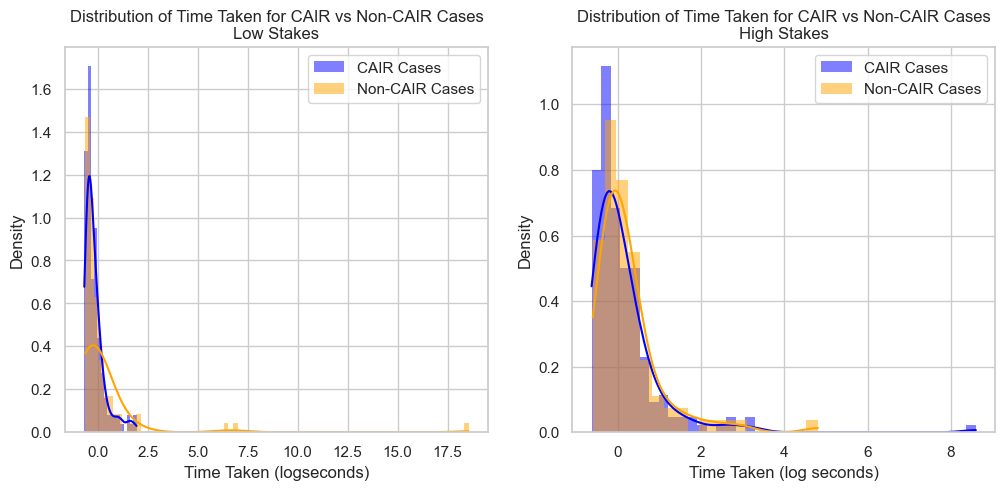

In [25]:
plt.figure(figsize=(12, 5))


time_col = 'z_time_taken_advised'

plt.subplot(1, 2, 1)
sns.histplot(df_low[cair_low][time_col], color='blue', label='CAIR Cases', kde=True, stat="density", linewidth=0)
sns.histplot(df_low[iair_low][time_col], color='orange', label='Non-CAIR Cases', kde=True, stat="density", linewidth=0)
plt.xlabel('Time Taken (logseconds)')
plt.ylabel('Density')
plt.title('Distribution of Time Taken for CAIR vs Non-CAIR Cases\nLow Stakes')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(df_high[cair_high][time_col], color='blue', label='CAIR Cases', kde=True, stat="density", linewidth=0)
sns.histplot(df_high[iair_high][time_col], color='orange', label='Non-CAIR Cases', kde=True, stat="density", linewidth=0)
plt.xlabel('Time Taken (log seconds)')
plt.ylabel('Density')
plt.title('Distribution of Time Taken for CAIR vs Non-CAIR Cases\nHigh Stakes')
plt.legend()

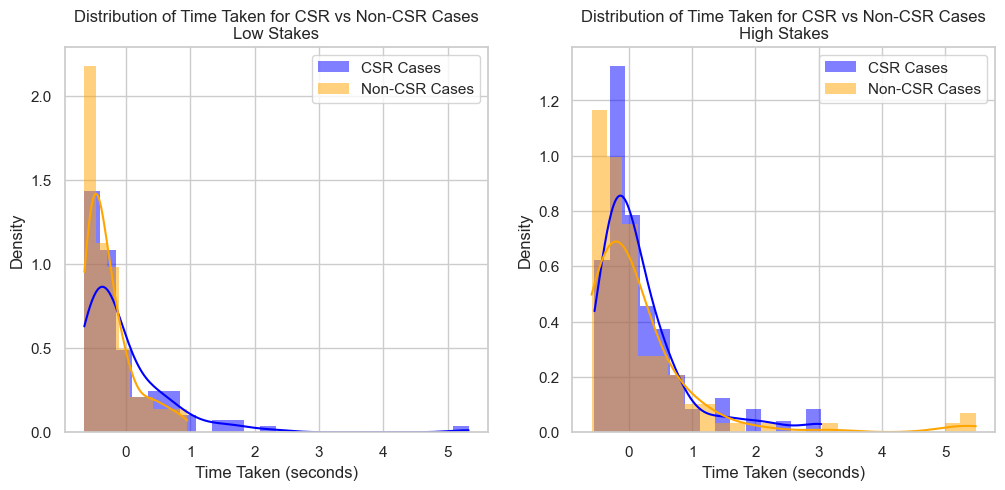

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_low[csr_low][time_col], color='blue', label='CSR Cases', kde=True, stat="density", linewidth=0)
sns.histplot(df_low[isr_low][time_col], color='orange', label='Non-CSR Cases', kde=True, stat="density", linewidth=0)
plt.xlabel('Time Taken (seconds)')
plt.ylabel('Density')
plt.title('Distribution of Time Taken for CSR vs Non-CSR Cases\nLow Stakes')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(df_high[csr_high][time_col], color='blue', label='CSR Cases', kde=True, stat="density", linewidth=0)
sns.histplot(df_high[isr_high][time_col], color='orange', label='Non-CSR Cases', kde=True, stat="density", linewidth=0)
plt.xlabel('Time Taken (seconds)')
plt.ylabel('Density')
plt.title('Distribution of Time Taken for CSR vs Non-CSR Cases\nHigh Stakes')
plt.legend()

In [27]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [28]:
df_all_cair = df_all[get_CAIR(df_all)].copy()
df_all_cair['CAIR'] = 1
df_all_iair = df_all[get_IAIR(df_all)].copy()
df_all_iair['CAIR'] = 0

df_all_comb = pd.concat([df_all_cair, df_all_iair], axis=0, ignore_index=True)
df_all_comb["z_log_time"] = (df_all_comb["log_time_taken_advised"] - df_all_comb["log_time_taken_advised"].mean()) / df_all_comb["log_time_taken_advised"].std()

df_all_comb.head()

,part_id,blocky_id,stakes_level,y_true,y_pred,y_user_base,y_user_advised,time_taken_base,time_taken_advised,z_time_taken_advised,log_time_taken_advised,z_log_time,CAIR
0,study1-05,0575626d-1155-4f79-a8ed-151c82499cee,low,0,0,1,0,2596.0,3.797,-0.364812,1.334211,-0.588745,1
1,study1-05,0a43a265-1afa-47a5-807e-402622e5b3c8,low,0,0,1,0,2010.0,4.397,-0.286653,1.480922,-0.364410,1
2,study1-05,2fdd906b-a9b2-4c4b-b66b-94ab1efb1f97,low,1,1,0,1,3791.0,2.567,-0.525038,0.942738,-1.187343,1
3,study1-05,6ee36074-0245-4135-b404-3158ecbfe6f5,low,1,1,0,1,4240.0,5.688,-0.118480,1.738359,0.029233,1
4,study1-05,a9560d62-361e-4028-b078-95afbe555b02,low,1,1,0,1,2483.0,3.702,-0.377187,1.308873,-0.627489,1


In [29]:
print(df_all_comb["time_taken_advised"].describe())
print("Any nonpositive times:", (df_all_comb[time_col] <= 0).sum())
print("CAIR rate overall:", df_all_comb["CAIR"].mean())
print(df_all_comb.groupby("stakes_level")["CAIR"].mean())

count    543.000000
mean       7.286411
std        8.948942
min        1.430000
25%        3.495000
50%        5.293000
75%        8.284000
max      148.990000
Name: time_taken_advised, dtype: float64
Any nonpositive times: 349
CAIR rate overall: 0.6335174953959485
stakes_level
low     0.599222
high    0.664336
Name: CAIR, dtype: float64


In [30]:
# --- GEE: correctness ~ log_time * stakes, clustered by user ---
gee = smf.gee(
    f"CAIR ~ {time_col} * stakes_level",
    groups="part_id",
    data=df_all_comb,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable()  # common choice
)
res = gee.fit()
print(res.summary())

                               GEE Regression Results                              
Dep. Variable:                        CAIR   No. Observations:                  543
Model:                                 GEE   No. clusters:                       52
Method:                        Generalized   Min. cluster size:                   2
                      Estimating Equations   Max. cluster size:                  18
Family:                           Binomial   Mean cluster size:                10.4
Dependence structure:         Exchangeable   Num. iterations:                     7
Date:                     Tue, 27 Jan 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         22:46:10
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept               

In [31]:
glm = smf.glm(
    f"CAIR ~ {time_col} * stakes_level",
    data=df_all_comb,
    family=sm.families.Binomial()
).fit()

print(glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   CAIR   No. Observations:                  543
Model:                            GLM   Df Residuals:                      539
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -352.43
Date:                Tue, 27 Jan 2026   Deviance:                       704.86
Time:                        22:46:10   Pearson chi2:                     541.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01590
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [32]:
import polars as pl

In [48]:
df = df_all_comb.copy()
df["CAIR"] = df["CAIR"].astype(int)
df["part_id"] = df["part_id"].astype("category")
df["blocky_id"] = df["blocky_id"].astype("category")

df_all_comb_pl = pl.DataFrame(df)

# GLMM logistic regression (logit link)
m_cair = glmer(
    f"CAIR ~ {time_col} * stakes_level + (1|part_id) + (1|blocky_id)",
    data=df_all_comb_pl,
    family="binomial"
)

gt = m_cair.fit(summary=True, exponentiate=True)

In [50]:
gt

GT(_tbl_data=shape: (8, 10)
┌────────────────┬──────────────────┬──────────┬──────────┬───┬───────────┬──────┬─────────┬───────┐
│ rfx            ┆ param            ┆ estimate ┆ conf_low ┆ … ┆ z_stat    ┆ df   ┆ p_value ┆ stars │
│ ---            ┆ ---              ┆ ---      ┆ ---      ┆   ┆ ---       ┆ ---  ┆ ---     ┆ ---   │
│ str            ┆ str              ┆ f64      ┆ f64      ┆   ┆ f64       ┆ f64  ┆ str     ┆ str   │
╞════════════════╪══════════════════╪══════════╪══════════╪═══╪═══════════╪══════╪═════════╪═══════╡
│ part_id-sd     ┆ (Intercept)      ┆ 0.851478 ┆ null     ┆ … ┆ null      ┆ null ┆ null    ┆ null  │
│ blocky_id-sd   ┆ (Intercept)      ┆ 0.383478 ┆ null     ┆ … ┆ null      ┆ null ┆ null    ┆ null  │
│ null           ┆ null             ┆ null     ┆ null     ┆ … ┆ null      ┆ null ┆ null    ┆ null  │
│ Fixed Effects: ┆ null             ┆ null     ┆ null     ┆ … ┆ null      ┆ null ┆ null    ┆ null  │
│ null           ┆ (Intercept)      ┆ 1.688025 ┆ 1.042849 ┆ … ┆ 2.130714  ┆ inf  ┆ 0.03311 ┆ *     │
│ null           ┆ z_time_taken_adv ┆ 0.584779 ┆ 0.347819 ┆ … ┆ -2.023985 ┆ inf  ┆ 0.04297 ┆ *     │
│                ┆ ised             ┆          ┆          ┆   ┆           ┆      ┆         ┆       │
│ null           ┆ stakes_levelhigh ┆ 1.421913 ┆ 0.764992 ┆ … ┆ 1.112956  ┆ inf  ┆ 0.2657  ┆       │
│ null           ┆ z_time_taken_adv ┆ 1.423199 ┆ 0.780364 ┆ … ┆ 1.151079  ┆ inf  ┆ 0.2497  ┆       │
│                ┆ ised:stakes_le…  ┆          ┆          ┆   ┆           ┆      ┆         ┆       │
└────────────────┴──────────────────┴──────────┴──────────┴───┴───────────┴──────┴─────────┴───────┘, _body=<great_tables._gt_data.Body object at 0x186c78340>, _boxhead=Boxhead([ColInfo(var='rfx', type=<ColInfoTypeEnum.default: 1>, column_label='Random Effects:', column_align='left', column_width=None), ColInfo(var='param', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='estimate', type=<ColInfoTypeEnum.default: 1>, column_label='Estimate', column_align='right', column_width=None), ColInfo(var='conf_low', type=<ColInfoTypeEnum.default: 1>, column_label='CI-low', column_align='right', column_width=None), ColInfo(var='conf_high', type=<ColInfoTypeEnum.default: 1>, column_label='CI-high', column_align='right', column_width=None), ColInfo(var='std_error', type=<ColInfoTypeEnum.default: 1>, column_label='SE', column_align='right', column_width=None), ColInfo(var='z_stat', type=<ColInfoTypeEnum.default: 1>, column_label='Z-stat', column_align='right', column_width=None), ColInfo(var='df', type=<ColInfoTypeEnum.default: 1>, column_label='df', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p', column_align='left', column_width=None), ColInfo(var='stars', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x18b287250>, _spanners=Spanners([]), _heading=Heading(title='Formula: glmer(CAIR~z_time_taken_advised*stakes_level+(1|part_id)+(1|blocky_id))', subtitle=Md(text='Family: *binomial (link: *default*)*  \n            Number of observations: *543*  \n            Confidence intervals: *parametric*  \n            ---------------------  \n            Log-likelihood: *-337*  \n            AIC: *686* | BIC: *712*  \n            Residual error: *1.0*  \n        '), preheader=None), _stubhead=None, _source_notes=[Md(text='Signif. codes: *0 *** 0.001 ** 0.01 * 0.05 . 0.1*')], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=['param'], rows=None, mask=None), grpname=None, colname='param', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style='italic', weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=['param'], rows=None, mask=None), grpname=None, colname='param', rownum=1, colnum=None, styles=[Cell

In [44]:
m_cair.report()

We fitted a logistic mixed model (estimated using ML and Nelder-Mead optimizer)
to predict CAIR with z_time_taken_advised and stakes_level (formula: CAIR ~
z_time_taken_advised * stakes_level). The model included part_id as random
effects (formula: list(~1 | part_id, ~1 | blocky_id)). The model's total
explanatory power is substantial (conditional R2 = 0.26) and the part related
to the fixed effects alone (marginal R2) is of 0.07. The model's intercept,
corresponding to z_time_taken_advised = 0 and stakes_level = low, is at 0.52
(95% CI [0.04, 1.01], p = 0.033). Within this model:

  - The effect of z time taken advised is statistically significant and negative
(beta = -0.54, 95% CI [-1.06, -0.02], p = 0.043; Std. beta = -0.63, 95% CI
[-1.23, -0.02])
  - The effect of stakes level [high] is statistically non-significant and
positive (beta = 0.35, 95% CI [-0.27, 0.97], p = 0.266; Std. beta = 0.38, 95%
CI [-0.24, 1.01])
  - The effect of z time taken advised × stakes level [high] is stat

In [49]:
# Extract underlying table
fe_df = pd.DataFrame(gt._tbl)
print(fe_df)





# print(fe.to_latex(
#     escape=True,
#     float_format="%.2f",
#     booktabs=True,
#     caption="Fixed-effects estimates from logistic mixed-effects model (log-odds scale).",
#     label="tab:glmer_fe",
# ))


AttributeError: 'GT' object has no attribute '_tbl'

In [33]:
# model = bmb.Model(
#     f"CAIR ~ {time_col} * stakes_level + (1|part_id) + (1|blocky_id)",
#     df_all_comb,
#     family="bernoulli"
# )

# idata_cair = model.fit(draws=2000, chains=4, target_accept=0.9)
# az.summary(idata_cair, var_names=[time_col, "stakes_level", f"{time_col}:stakes_level"], hdi_prob=0.95)

In [34]:
# post = idata_cair.posterior

# beta_time = post[time_col].values.flatten()
# p_neg = (beta_time < 0).mean()
# p_pos = (beta_time > 0).mean()
# p_direction = max(p_neg, p_pos)

# beta_stakes = post["stakes_level"].values.flatten()
# p_neg_stakes = (beta_stakes < 0).mean()
# p_pos_stakes = (beta_stakes > 0).mean()
# p_direction_stakes = max(p_neg_stakes, p_pos_stakes)

# beta_time_stakes = post[f"{time_col}:stakes_level"].values.flatten()
# p_neg_time_stakes = (beta_time_stakes < 0).mean()
# p_pos_time_stakes = (beta_time_stakes > 0).mean()
# p_direction_time_stakes = max(p_neg_time_stakes, p_pos_time_stakes)

# print(f'Posterior probability that {time_col} has a {"negative" if p_neg > p_pos else "positive"} effect on CAIR: {p_direction:.4f}')
# print(f'Posterior probability that stakes_level[high] has a {"negative" if p_neg_stakes > p_pos_stakes else "positive"} effect on CAIR: {p_direction_stakes:.4f}')
# print(f'Posterior probability that interaction {time_col}:stakes_level[high] has a {"negative" if p_neg_time_stakes > p_pos_time_stakes else "positive"} effect on CAIR: {p_direction_time_stakes:.4f}')



In [35]:
# az.summary(
#     idata_cair,
#     var_names=["1|part_id_sigma", "1|blocky_id_sigma"],
#     hdi_prob=0.95
# )


In [36]:
# model = bmb.Model(
#     f"CAIR ~ {time_col} * stakes_level + (1 + {time_col} | part_id) + (1 | blocky_id)",
#     df_all_comb,
#     family="bernoulli"
# )
# idata = model.fit(draws=2000, chains=4, target_accept=0.95)
# az.summary(idata, var_names=["1|part_id_sigma", f"{time_col}|part_id_sigma", "1|blocky_id_sigma"])

In [37]:
df_all_csr = df_all[get_CSR(df_all)].copy()
df_all_csr['CSR'] = 1
df_all_isr = df_all[get_ISR(df_all)].copy()
df_all_isr['CSR'] = 0

df_all_comb_csr = pd.concat([df_all_csr, df_all_isr], axis=0, ignore_index=True)
df_all_comb_csr["z_log_time"] = (df_all_comb_csr["log_time_taken_advised"] - df_all_comb_csr["log_time_taken_advised"].mean()) / df_all_comb_csr["log_time_taken_advised"].std()

df_all_comb.head()

,part_id,blocky_id,stakes_level,y_true,y_pred,y_user_base,y_user_advised,time_taken_base,time_taken_advised,z_time_taken_advised,log_time_taken_advised,z_log_time,CAIR
0,study1-05,0575626d-1155-4f79-a8ed-151c82499cee,low,0,0,1,0,2596.0,3.797,-0.364812,1.334211,-0.588745,1
1,study1-05,0a43a265-1afa-47a5-807e-402622e5b3c8,low,0,0,1,0,2010.0,4.397,-0.286653,1.480922,-0.364410,1
2,study1-05,2fdd906b-a9b2-4c4b-b66b-94ab1efb1f97,low,1,1,0,1,3791.0,2.567,-0.525038,0.942738,-1.187343,1
3,study1-05,6ee36074-0245-4135-b404-3158ecbfe6f5,low,1,1,0,1,4240.0,5.688,-0.118480,1.738359,0.029233,1
4,study1-05,a9560d62-361e-4028-b078-95afbe555b02,low,1,1,0,1,2483.0,3.702,-0.377187,1.308873,-0.627489,1


In [38]:
# --- GEE: correctness ~ log_time * stakes, clustered by user ---
gee = smf.gee(
    f"CSR ~ {time_col} * stakes_level",
    groups="part_id",
    data=df_all_comb_csr,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable()  # common choice
)
res = gee.fit()
print(res.summary())

                               GEE Regression Results                              
Dep. Variable:                         CSR   No. Observations:                  416
Model:                                 GEE   No. clusters:                       52
Method:                        Generalized   Min. cluster size:                   5
                      Estimating Equations   Max. cluster size:                  10
Family:                           Binomial   Mean cluster size:                 8.0
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Sun, 25 Jan 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         23:46:55
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept               

In [39]:
glm = smf.glm(
    f"CSR ~ {time_col} * stakes_level",
    data=df_all_comb_csr,
    family=sm.families.Binomial()
).fit()

print(glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    CSR   No. Observations:                  416
Model:                            GLM   Df Residuals:                      412
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -280.83
Date:                Sun, 25 Jan 2026   Deviance:                       561.66
Time:                        23:46:55   Pearson chi2:                     414.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.03407
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [68]:
df = df_all_comb_csr.copy()
df["CSR"] = df["CSR"].astype(int)
df["part_id"] = df["part_id"].astype("category")
df["blocky_id"] = df["blocky_id"].astype("category")

df_all_comb_pl = pl.DataFrame(df)

# GLMM logistic regression (logit link)
m_csr = glmer(
    f"CSR ~ {time_col} * stakes_level + (1|part_id) + (1|blocky_id)",
    data=df_all_comb_pl,
    family="binomial"
)

m_csr.fit(summary=True, exponentiate=True)

GT(_tbl_data=shape: (8, 10)
┌────────────────┬─────────────────┬──────────┬──────────┬───┬───────────┬──────┬──────────┬───────┐
│ rfx            ┆ param           ┆ estimate ┆ conf_low ┆ … ┆ z_stat    ┆ df   ┆ p_value  ┆ stars │
│ ---            ┆ ---             ┆ ---      ┆ ---      ┆   ┆ ---       ┆ ---  ┆ ---      ┆ ---   │
│ str            ┆ str             ┆ f64      ┆ f64      ┆   ┆ f64       ┆ f64  ┆ str      ┆ str   │
╞════════════════╪═════════════════╪══════════╪══════════╪═══╪═══════════╪══════╪══════════╪═══════╡
│ part_id-sd     ┆ (Intercept)     ┆ 1.287046 ┆ null     ┆ … ┆ null      ┆ null ┆ null     ┆ null  │
│ blocky_id-sd   ┆ (Intercept)     ┆ 0.779414 ┆ null     ┆ … ┆ null      ┆ null ┆ null     ┆ null  │
│ null           ┆ null            ┆ null     ┆ null     ┆ … ┆ null      ┆ null ┆ null     ┆ null  │
│ Fixed Effects: ┆ null            ┆ null     ┆ null     ┆ … ┆ null      ┆ null ┆ null     ┆ null  │
│ null           ┆ (Intercept)     ┆ 1.867297 ┆ 0.842275 ┆ … ┆ 1.537393  ┆ inf  ┆ 0.1242   ┆       │
│ null           ┆ z_time_taken_ad ┆ 4.030143 ┆ 1.400399 ┆ … ┆ 2.584377  ┆ inf  ┆ 0.009756 ┆ **    │
│                ┆ vised           ┆          ┆          ┆   ┆           ┆      ┆          ┆       │
│ null           ┆ stakes_levelhig ┆ 0.394408 ┆ 0.1635   ┆ … ┆ -2.07081  ┆ inf  ┆ 0.03838  ┆ *     │
│                ┆ h               ┆          ┆          ┆   ┆           ┆      ┆          ┆       │
│ null           ┆ z_time_taken_ad ┆ 0.246801 ┆ 0.080177 ┆ … ┆ -2.439046 ┆ inf  ┆ 0.01473  ┆ *     │
│                ┆ vised:stakes_le ┆          ┆          ┆   ┆           ┆      ┆          ┆       │
│                ┆ …               ┆          ┆          ┆   ┆           ┆      ┆          ┆       │
└────────────────┴─────────────────┴──────────┴──────────┴───┴───────────┴──────┴──────────┴───────┘, _body=<great_tables._gt_data.Body object at 0x18b872020>, _boxhead=Boxhead([ColInfo(var='rfx', type=<ColInfoTypeEnum.default: 1>, column_label='Random Effects:', column_align='left', column_width=None), ColInfo(var='param', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='estimate', type=<ColInfoTypeEnum.default: 1>, column_label='Estimate', column_align='right', column_width=None), ColInfo(var='conf_low', type=<ColInfoTypeEnum.default: 1>, column_label='CI-low', column_align='right', column_width=None), ColInfo(var='conf_high', type=<ColInfoTypeEnum.default: 1>, column_label='CI-high', column_align='right', column_width=None), ColInfo(var='std_error', type=<ColInfoTypeEnum.default: 1>, column_label='SE', column_align='right', column_width=None), ColInfo(var='z_stat', type=<ColInfoTypeEnum.default: 1>, column_label='Z-stat', column_align='right', column_width=None), ColInfo(var='df', type=<ColInfoTypeEnum.default: 1>, column_label='df', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p', column_align='left', column_width=None), ColInfo(var='stars', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x18b9d95a0>, _spanners=Spanners([]), _heading=Heading(title='Formula: glmer(CSR~z_time_taken_advised*stakes_level+(1|part_id)+(1|blocky_id))', subtitle=Md(text='Family: *binomial (link: *default*)*  \n            Number of observations: *416*  \n            Confidence intervals: *parametric*  \n            ---------------------  \n            Log-likelihood: *-252*  \n            AIC: *516* | BIC: *540*  \n            Residual error: *1.0*  \n        '), preheader=None), _stubhead=None, _source_notes=[Md(text='Signif. codes: *0 *** 0.001 ** 0.01 * 0.05 . 0.1*')], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=['param'], rows=None, mask=None), grpname=None, colname='param', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style='italic', weight=None

In [67]:
m_csr.report()

We fitted a logistic mixed model (estimated using ML and Nelder-Mead optimizer)
to predict CSR with z_time_taken_advised and stakes_level (formula: CSR ~
z_time_taken_advised * stakes_level). The model included part_id as random
effects (formula: list(~1 | part_id, ~1 | blocky_id)). The model's total
explanatory power is substantial (conditional R2 = 0.46) and the part related
to the fixed effects alone (marginal R2) is of 0.08. The model's intercept,
corresponding to z_time_taken_advised = 0 and stakes_level = low, is at 0.62
(95% CI [-0.17, 1.42], p = 0.124). Within this model:

  - The effect of z time taken advised is statistically significant and positive
(beta = 1.39, 95% CI [0.34, 2.45], p = 0.010; Std. beta = 1.10, 95% CI [0.27,
1.94])
  - The effect of stakes level [high] is statistically significant and negative
(beta = -0.93, 95% CI [-1.81, -0.05], p = 0.038; Std. beta = -0.98, 95% CI
[-1.86, -0.09])
  - The effect of z time taken advised × stakes level [high] is statistical

In [40]:
# model = bmb.Model(
#     f"CSR ~ {time_col} * stakes_level + (1|part_id) + (1|blocky_id)",
#     df_all_comb_csr,
#     family="bernoulli"
# )

# idata_csr = model.fit(draws=2000, chains=4, target_accept=0.9)
# az.summary(idata_csr, var_names=[time_col, "stakes_level", f"{time_col}:stakes_level"], hdi_prob=0.95)

In [41]:
# post = idata_csr.posterior

# beta_time = post[time_col].values.flatten()
# p_neg = (beta_time < 0).mean()
# p_pos = (beta_time > 0).mean()
# p_direction = max(p_neg, p_pos)

# beta_stakes = post["stakes_level"].values.flatten()
# p_neg_stakes = (beta_stakes < 0).mean()
# p_pos_stakes = (beta_stakes > 0).mean()
# p_direction_stakes = max(p_neg_stakes, p_pos_stakes)

# beta_time_stakes = post[f"{time_col}:stakes_level"].values.flatten()
# p_neg_time_stakes = (beta_time_stakes < 0).mean()
# p_pos_time_stakes = (beta_time_stakes > 0).mean()
# p_direction_time_stakes = max(p_neg_time_stakes, p_pos_time_stakes)

# print(f'Posterior probability that {time_col} has a {"negative" if p_neg > p_pos else "positive"} effect on CSR: {p_direction:.4f}')
# print(f'Posterior probability that stakes_level[high] has a {"negative" if p_neg_stakes > p_pos_stakes else "positive"} effect on CSR: {p_direction_stakes:.4f}')
# print(f'Posterior probability that interaction {time_col}:stakes_level[high] has a {"negative" if p_neg_time_stakes > p_pos_time_stakes else "positive"} effect on CSR: {p_direction_time_stakes:.4f}')


In [42]:
# az.summary(
#     idata_csr,
#     var_names=["1|part_id_sigma", "1|blocky_id_sigma"],
#     hdi_prob=0.95
# )

In [43]:
# model = bmb.Model(
#     f"CSR ~ {time_col} * stakes_level + (1 + {time_col} | part_id) + (1 | blocky_id)",
#     df_all_comb_csr,
#     family="bernoulli"
# )
# idata = model.fit(draws=2000, chains=4, target_accept=0.9)
# az.summary(idata, var_names=["sd_part_id__Intercept", f"sd_part_id__{time_col}"])